In [1]:
from pathlib import Path

import numpy as onp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
BASERESULTSDIR = Path("out/")

# QUANTITY = "energy"
QUANTITY = "forces"

resultsdir = BASERESULTSDIR / "nonperiodic"
# resultsdir = BASERESULTSDIR / "periodic"

results = pd.read_csv(resultsdir / "results.csv")

In [3]:
unique_ps = results.loc[results["quantity"] == QUANTITY, "p"].unique()
unique_ps = onp.sort(unique_ps)

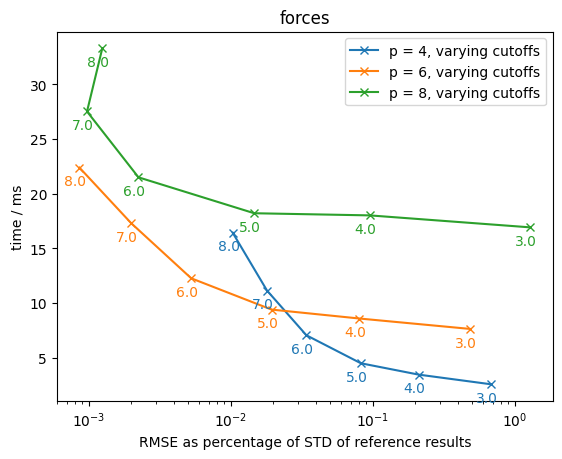

In [7]:
marker = "x"  # TODO: use different for each graph

fig, ax = plt.subplots()
ax.set_title(QUANTITY)
# TODO: percentage or fraction?
ax.set_xlabel("RMSE as percentage of STD of reference results")
ax.set_ylabel("time / ms")
ax.set_xscale("log")

ha = "center"
va = "top"
dx, dy = -3 / 72.0, -5 / 72.0
offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
annotations_transform = ax.transData + offset

# ha = "left"
# va = "bottom"
# dx, dy = 3 / 72.0, 3 / 72.0
# offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# annotations_transform = ax.transData + offset

for p in unique_ps:
    selection = results.loc[
        ((results["p"] == p) & (results["quantity"] == QUANTITY))
    ]
    cutoffs = selection.level_zero_cutoff
    errors = selection.error
    times = selection.time * 10**3
    graph = ax.plot(
        errors,
        times,
        marker=marker,
        label=f"p = {p}, varying cutoffs",
    )
    for r_cut, err, t in zip(cutoffs, errors, times):
        xy = (err, t)
        ax.annotate(
            str(r_cut),
            xy,
            xytext=xy,
            textcoords=annotations_transform,
            ha=ha,
            va=va,
            color=graph[0].get_color(),
        )

ax.legend()

plt.show()